# ■ 딥러닝 컴페티션

### 컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## ■ 깃허브 정리 (10점)

1. 포트폴리오로 쓸 수 있도록 프로젝트 제목, 전처리, EDA, 모델링 방법, 성능 결과를 캡처 이미지와 함께 잘 정리.

</br>

## ■ 제출방법

5월 12일 23시 59분까지, 오승환 강사에게 DM으로 ipynb 파일 제출, 이후 깃허브 링크도 정리되는대로 DM 제출

# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

file_path = 'train2.csv'
data = pd.read_csv(file_path)

data = data.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])

categorical_columns = ['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

target_encoder = LabelEncoder()
data['Credit_Score'] = target_encoder.fit_transform(data['Credit_Score'])

X = data.drop('Credit_Score', axis=1).values
y = data['Credit_Score'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class CreditScoreDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = CreditScoreDataset(X_train, y_train)
test_dataset = CreditScoreDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


input_size = X_train.shape[1]
model = MLP(input_size).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    model.eval()
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()

    train_accuracy = 100 * correct_train / total_train
    val_accuracy = 100 * correct_val / total_val
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
          f'학습 정확도: {train_accuracy:.2f}%, 평가 정확도: {val_accuracy:.2f}%')


AttributeError: partially initialized module 'torch' has no attribute 'fx' (most likely due to a circular import)

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

In [135]:
file_path = 'train2.csv'
data = pd.read_csv(file_path)

# 데이터를 불러왔습니다.

In [136]:
data = data.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])


# ID, 고객 ID, 이름, 주민번호는 고객을 식별하기 위한 정보이기에
# 신용 등급 자체와는 관련이 낮다고 판단하여 제거하였습니다.

In [137]:
# 데이터 전처리 방식을 다르게 해야하기에 범주형 변수와 수치형 변수를 구분하였습니다.

categorical_columns = [
    'Occupation',
    'Type_of_Loan',
    'Credit_Mix',
    'Payment_of_Min_Amount',
    'Payment_Behaviour'
]

# 범주형 변수 목록을 만들었습니다.

numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# int64, float64를 사용하여 수치형 변수 목록을 만들었습니다.

In [138]:
if 'Credit_Score' in numeric_columns:
    numeric_columns.remove('Credit_Score')

for col in numeric_columns:
  data[col] = data[col].fillna(data[col].mean())

for col in categorical_columns:
  data[col] = data[col].fillna(data[col].mode()[0])


# 신용 점수 같은 경우 정답값이기에 전처리에서 제거하였습니다.
# 수치형 데이터의 결측치는 평균값으로 채워넣었습니다.
# 범주형 데이터의 결측치는 최빈값으로 채워넣었습니다.

In [139]:
for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))

target_encoder = LabelEncoder()

data['Credit_Score'] = target_encoder.fit_transform(data['Credit_Score'])

# 범주형 변수를 라벨인코딩을 통하여 숫자로 변환하였다.
# 정답값인 신용점수 또한 숫자로 변환하였습니다.

In [140]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Month                     100000 non-null  int64  
 1   Age                       100000 non-null  int64  
 2   Occupation                100000 non-null  int64  
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     100000 non-null  float64
 5   Num_Bank_Accounts         100000 non-null  int64  
 6   Num_Credit_Card           100000 non-null  int64  
 7   Interest_Rate             100000 non-null  int64  
 8   Num_of_Loan               100000 non-null  int64  
 9   Type_of_Loan              100000 non-null  int64  
 10  Delay_from_due_date       100000 non-null  int64  
 11  Num_of_Delayed_Payment    100000 non-null  int64  
 12  Changed_Credit_Limit      100000 non-null  float64
 13  Num_Credit_Inquiries      100000 non-null  in

In [141]:
print(data.describe())

               Month            Age     Occupation  Annual_Income  \
count  100000.000000  100000.000000  100000.000000  100000.000000   
mean        4.500000      33.316340       6.949840   50505.123449   
std         2.291299      10.764812       4.309542   38299.422093   
min         1.000000      14.000000       0.000000    7005.930000   
25%         2.750000      24.000000       3.000000   19342.972500   
50%         4.500000      33.000000       7.000000   36999.705000   
75%         6.250000      42.000000      11.000000   71683.470000   
max         8.000000      56.000000      14.000000  179987.280000   

       Monthly_Inhand_Salary  Num_Bank_Accounts  Num_Credit_Card  \
count          100000.000000      100000.000000    100000.000000   
mean             4197.270835           5.368820         5.533570   
std              3186.432497           2.593314         2.067098   
min               303.645417           0.000000         0.000000   
25%              1626.594167          

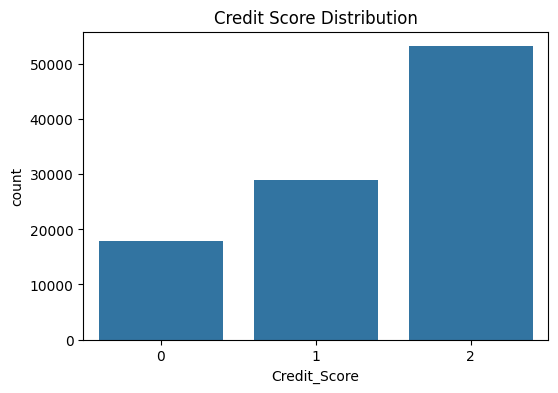

In [142]:
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_Score',data=data)
plt.title('Credit Score Distribution')
plt.show()

# 신용등급 클래스 분포를 확인해봤습니다.
# 0등급은 Good, 1등급은 Poor, 2등급은 Standard로 인코딩 되었기에 Standard 등급이 가장 많았고,
# 다음으로는 Poor가 높았습니다.
# 마지막으로 Good 등급이 가장 적었습니다.

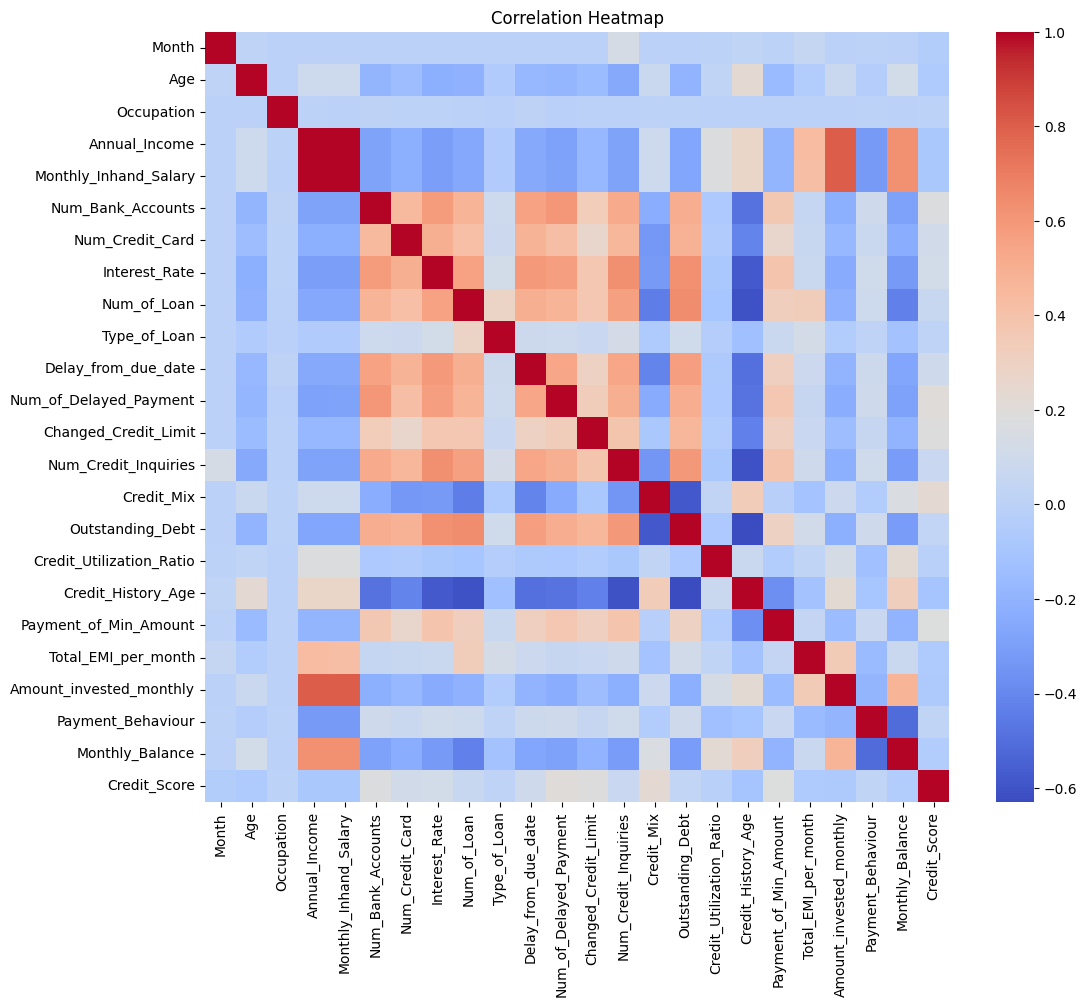

In [143]:
plt.figure(figsize=(12,10))
correlation = data.corr(numeric_only=True)
sns.heatmap(correlation,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 변수 간에 상관관계를 시각화하여 신용등급에 영향을 미치는 주요 변수를 보았습니다.
# 히트맵을 요약해보자면 소득 수준과 부채, 연체 여부가 신용등급 예측에 중요한 영향을 미친다는 것을 알 수 있었습니다.

In [144]:
X = data.drop('Credit_Score',axis=1)
y = data['Credit_Score']

# X에는 정답값을 제외한 나머지 칼럼을 지정하였습니다.
# y에는 정답값인 신용점수를 지정하였습니다.

In [145]:
correlation_matrix = data.corr()
correlation_matrix

# 변수 간 상관관계를 수치로 본 결과 Montly_Inhead_Salery가 Annual_Income과 약 0.99로 매우 높은 수치를 보였다.


,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
Month,1.000000e+00,0.016990,2.048899e-16,1.549470e-17,-0.001819,0.000079,0.000090,6.790115e-18,1.555542e-16,1.212385e-16,...,-1.025995e-16,3.200578e-17,0.002440,0.022784,0.001287,0.049716,-1.048392e-16,0.004191,-0.002095,-0.038069
Age,1.698955e-02,1.000000,-3.965696e-03,9.152456e-02,0.090636,-0.190415,-0.148567,-2.175571e-01,-2.135330e-01,-5.129988e-02,...,7.338015e-02,-2.023741e-01,0.025492,0.234618,-0.162497,-0.047334,7.104515e-02,-0.034098,0.116098,-0.058923
Occupation,2.048899e-16,-0.003966,1.000000e+00,1.270171e-03,0.000763,0.010430,0.003474,4.501347e-03,-5.037742e-03,-6.571299e-03,...,6.262513e-03,6.455418e-03,0.000197,-0.005178,-0.004319,0.000550,5.498126e-04,0.004253,-0.002208,0.005548
Annual_Income,1.549470e-17,0.091525,1.270171e-03,1.000000e+00,0.998154,-0.284060,-0.217852,-3.023524e-01,-2.555596e-01,-5.175124e-02,...,9.399074e-02,-2.693193e-01,0.175930,0.272374,-0.194421,0.438106,8.062806e-01,-0.320805,0.625640,-0.080700
Monthly_Inhand_Salary,-1.818625e-03,0.090636,7.625631e-04,9.981538e-01,1.000000,-0.283181,-0.216847,-3.018580e-01,-2.542982e-01,-5.111049e-02,...,9.364361e-02,-2.690445e-01,0.176092,0.271457,-0.193842,0.421836,8.073264e-01,-0.322385,0.626631,-0.078770
Num_Bank_Accounts,7.909795e-05,-0.190415,1.042960e-02,-2.840602e-01,-0.283181,1.000000,0.442694,5.843015e-01,4.724831e-01,9.275896e-02,...,-2.287226e-01,5.070634e-01,-0.071783,-0.485331,0.364265,0.050035,-2.278278e-01,0.099273,-0.286709,0.177389
Num_Credit_Card,8.973261e-05,-0.148567,3.473656e-03,-2.178520e-01,-0.216847,0.442694,1.000000,4.979115e-01,4.179595e-01,7.858830e-02,...,-3.343182e-01,4.903760e-01,-0.055249,-0.417205,0.259624,0.058853,-1.746004e-01,0.075434,-0.231913,0.113333
Interest_Rate,6.790115e-18,-0.217557,4.501347e-03,-3.023524e-01,-0.301858,0.584302,0.497912,1.000000e+00,5.591562e-01,1.194085e-01,...,-3.208077e-01,6.294144e-01,-0.075700,-0.576230,0.391145,0.071651,-2.424790e-01,0.108659,-0.317919,0.121088
Num_of_Loan,1.555542e-16,-0.213533,-5.037742e-03,-2.555596e-01,-0.254298,0.472483,0.417960,5.591562e-01,1.000000e+00,2.811485e-01,...,-4.446627e-01,6.387126e-01,-0.100469,-0.605727,0.323988,0.328485,-2.142544e-01,0.094942,-0.429416,0.064064
Type_of_Loan,1.212385e-16,-0.051300,-6.571299e-03,-5.175124e-02,-0.051110,0.092759,0.078588,1.194085e-01,2.811485e-01,1.000000e+00,...,-5.976091e-02,1.077762e-01,-0.033822,-0.127716,0.072462,0.126612,-4.558901e-02,0.019768,-0.120157,0.014924


In [146]:
drop_columns = ['Monthly_Inhand_Salary']

data = data.drop(columns=drop_columns)

# 이 변수가 들어가게 된다면 상관관계가 매우 높기에 과적합이 일어날 수 있다고 판단하여 제거하였습니다.


In [147]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 스탠다드 스케일러로 리스케일링을 진행하였습니다.

In [148]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 8:2로 나눴고 위에서 봤듯이 등급에 불균형이 있어 stratify 옵션을 활용하여 클래스 비율이 유지되도록 하였습니다.

In [161]:
tabnet_model = TabNetClassifier(
    n_d=64,
    n_a=64,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,

    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict( lr=0.02 ),
    scheduler_params={"step_size":20,"gamma":0.9 },
    scheduler_fn=torch.optim.lr_scheduler.StepLR, mask_type='entmax' )

# 모델은 TabNet을 활용하였습니다.
# TabNet은 구조상 큰 Learning Rate가 필요하므로 0.02로 설정하였으며,
# Weight Decay를 통해 가중치 억제를 적용하여 과적합을 방지했습니다.
# mask_type을 'entmax'로 설정하여 중요도가 낮은 변수는 더 확실하게 0으로 처리하도록 유도했습니다.

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [162]:
tabnet_model.fit(

    X_train=X_train,
    y_train=y_train,

    eval_set=[(X_test, y_test)],
    eval_name=['validation'],
    eval_metric=['accuracy'],

    max_epochs=50,
    patience=15,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=4,
    drop_last=False
)

# 최대 50 에폭을 반복하되, 조기 종료를 통해 최적의 지점에서 학습을 멈추도록 설계했습니다.
# 15번의 에폭 동안 검증 정확도가 개선되지 않으면 학습을 자동 종료하여 과적합을 방지하도록 하였습니다.
# TabNet의 Ghost Batch Normalization 효과를 극대화하기 위해 전체 배치 사이즈를 1024로 크게 설정했습니다.
# 가상 배치(Virtual Batch)를 128로 설정하여 대규모 배치에서도 디테일한 학습이 가능하게 했습니다.
# 데이터 로딩의 빠른 처리를 위해 num_workers를 설정하여 학습 속도를 최적화했습니다.
# 데이터 손실을 방지하기 위해 마지막 배치가 배치 사이즈보다 작더라도 버리지 않고 학습에 포함했습니다.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


epoch 0  | loss: 0.87753 | validation_accuracy: 0.65135 |  0:00:07s


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


epoch 1  | loss: 0.71761 | validation_accuracy: 0.67955 |  0:00:13s


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


epoch 48 | loss: 0.4057  | validation_accuracy: 0.7917  |  0:05:36s


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


epoch 49 | loss: 0.39994 | validation_accuracy: 0.7935  |  0:05:46s
Stop training because you reached max_epochs = 50 with best_epoch = 49 and best_validation_accuracy = 0.7935


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [164]:
preds = tabnet_model.predict(X_test)

accuracy = accuracy_score(y_test,preds)

print(f'Validation Accuracy: 'f'{accuracy * 100:.2f}%')

print(classification_report(y_test,preds))

# 최종 결과 Validation Accuracy는 79.35%가 나오게 되었습니다.

Validation Accuracy: 79.35%
              precision    recall  f1-score   support

           0       0.74      0.79      0.76      3566
           1       0.77      0.82      0.80      5799
           2       0.83      0.78      0.80     10635

    accuracy                           0.79     20000
   macro avg       0.78      0.80      0.79     20000
weighted avg       0.80      0.79      0.79     20000



In [86]:
# 개선사항

# Feature Selection을 적용하여 중요한 변수만 선택하였습니다.
# TabNet 모델을 적용하여 tabular 데이터 학습 성능을 향상시켰습니다.
# Attention 기반 구조를 통해 중요한 feature를 선택적으로 학습하였습니다.
# Early Stopping을 적용하여 과적합을 방지하였습니다.
# Heatmap과 Countplot을 통해 데이터 분포와 변수 관계를 시각화하였습니다.
# Stratify를 적용하여 클래스 비율 불균형 문제를 완화하였습니다.
# 상관관계 분석을 통해 Annual_Income과 Monthly_Inhand_Salary 간의 매우 높은 상관성(0.99)을 확인하고, 과적합 방지를 위해 중복 변수를 제거하여 모델의 안정성을 높였습니다.